## Train Relation Head on OpenPSG with Cached Mask2Former Features

Two-phase pipeline:
1. **Cache** (run once): Extract top-K query + mask-pooled pixel-decoder features from a frozen Mask2Former for every image, match GT segments, build relation targets, and save to disk as `.pt` files.
2. **Train** (run repeatedly): Load cached features and train only the RelationHead — no Mask2Former forward pass needed.

In [13]:
import os
import json
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/home/abdou/Projects/Python/RTSGS")
PSG_JSON_PATH = PROJECT_ROOT / "Datasets" / "psg" / "psg.json"
COCO_ROOT = PROJECT_ROOT / "Datasets" / "coco" / "coco"

CHECKPOINT = "facebook/mask2former-swin-large-coco-panoptic"
TOP_K = 20
BATCH_SIZE = 16

LR = 1e-4
WEIGHT_DECAY = 5e-4
IOU_THRESHOLD = 0.5
THRESHOLD = 0.5
NEG_RATIO = 30
RANDOM_FRACTION = 0.20
MIN_NEGATIVES = 100
FOCAL_GAMMA = 2.0
WARMUP_EPOCHS = 5
EMA_DECAY = 0.999
DROPOUT = 0.2
FEAT_DROP = 0.3
LABEL_SMOOTHING = 0.1
SEED = 42
LIMIT = None

SAVE_PATH = PROJECT_ROOT / "SceneGraph" / "relation_head_psg.pt"
CACHE_DIR = PROJECT_ROOT / "Datasets" / "psg" / "cached_features"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Limit: {LIMIT}" if LIMIT is not None else "Limit: None (full dataset)")

Device: cuda
Limit: None (full dataset)


In [14]:
with open(PSG_JSON_PATH) as f:
    psg = json.load(f)

thing_classes = psg["thing_classes"]
stuff_classes = psg["stuff_classes"]
predicate_classes = psg["predicate_classes"]
all_classes = thing_classes + stuff_classes
test_image_ids = set(str(x) for x in psg["test_image_ids"])
num_predicates = len(predicate_classes)

all_data = psg["data"]
train_data = [d for d in all_data if str(d["image_id"]) not in test_image_ids and len(d["relations"]) > 0]
val_data = [d for d in all_data if str(d["image_id"]) in test_image_ids and len(d["relations"]) > 0]

print(f"Object classes: {len(all_classes)} ({len(thing_classes)} things + {len(stuff_classes)} stuff)")
print(f"Predicate classes: {num_predicates}")
print(f"Train (with relations): {len(train_data)}")
print(f"Val/Test (with relations): {len(val_data)}")

pred_counts = torch.zeros(num_predicates)
for d in train_data:
    for s, o, p in d["relations"]:
        if 0 <= p < num_predicates:
            pred_counts[p] += 1

pred_weights = 1.0 / torch.sqrt(pred_counts.clamp(min=1))
pred_weights = pred_weights / pred_weights.mean()

top5 = pred_weights.argsort(descending=True)[:5]
bot5 = pred_weights.argsort()[:5]
print(f"\nPredicate weight range: {pred_weights.min():.2f} - {pred_weights.max():.2f}")
print(f"Highest weighted (rare): {[(predicate_classes[i], f'{pred_weights[i]:.1f}', f'n={int(pred_counts[i])}') for i in top5.tolist()]}")
print(f"Lowest weighted (freq):  {[(predicate_classes[i], f'{pred_weights[i]:.2f}', f'n={int(pred_counts[i])}') for i in bot5.tolist()]}")

Object classes: 133 (80 things + 53 stuff)
Predicate classes: 56
Train (with relations): 45697
Val/Test (with relations): 2177

Predicate weight range: 0.05 - 4.39
Highest weighted (rare): [('opening', '4.4', 'n=7'), ('falling off', '4.4', 'n=7'), ('picking', '4.1', 'n=8'), ('climbing', '3.7', 'n=10'), ('kissing', '2.9', 'n=16')]
Lowest weighted (freq):  [('on', '0.05', 'n=52974'), ('beside', '0.05', 'n=45032'), ('over', '0.06', 'n=39332'), ('attached to', '0.08', 'n=20484'), ('standing on', '0.09', 'n=18412')]


In [15]:
def decode_panoptic_png(pan_array):
    """COCO panoptic format: id = R + G*256 + B*65536."""
    return (
        pan_array[:, :, 0].astype(np.int64)
        + pan_array[:, :, 1].astype(np.int64) * 256
        + pan_array[:, :, 2].astype(np.int64) * 65536
    )


def get_pixel_decoder_features(outputs):
    if hasattr(outputs, "pixel_decoder_last_hidden_state") and outputs.pixel_decoder_last_hidden_state is not None:
        return outputs.pixel_decoder_last_hidden_state
    if hasattr(outputs, "pixel_decoder_hidden_states") and outputs.pixel_decoder_hidden_states is not None:
        return outputs.pixel_decoder_hidden_states[-1]
    raise RuntimeError("Pixel decoder features not found.")


def mask_pool_pixel_features(pixel_features, mask_logits):
    if mask_logits.shape[-2:] != pixel_features.shape[-2:]:
        mask_logits = F.interpolate(
            mask_logits, size=pixel_features.shape[-2:],
            mode="bilinear", align_corners=False,
        )
    masks = torch.sigmoid(mask_logits)
    masks = masks / (masks.sum(dim=(2, 3), keepdim=True) + 1e-6)
    return torch.einsum("bchw,bnhw->bnc", pixel_features, masks).squeeze(0)


def extract_topk_features(outputs, top_k):
    """Top-K query + mask-pooled pixel features. Gradient flows through Mask2Former outputs."""
    logits = outputs.class_queries_logits.squeeze(0)
    scores = F.softmax(logits, dim=-1)[:, :-1].max(dim=1).values
    k = min(top_k, scores.shape[0])
    topk = torch.topk(scores, k=k)

    queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)
    queries_topk = queries[topk.indices]

    pixel_features = get_pixel_decoder_features(outputs)
    pooled = mask_pool_pixel_features(pixel_features, outputs.masks_queries_logits)
    pooled_topk = pooled[topk.indices]

    object_features = torch.cat([queries_topk, pooled_topk], dim=-1).unsqueeze(0)
    return object_features, topk.indices.detach().cpu()


def match_gt_to_topk(gt_pan_ids, segments_info, mask_logits, original_hw, topk_indices,
                     iou_thr=0.3, pred_classes=None):
    """Match GT panoptic segments to top-K predicted queries via mask IoU + optional class check."""
    with torch.no_grad():
        topk_masks = F.interpolate(
            mask_logits[:, topk_indices.to(mask_logits.device)].float(),
            size=original_hw, mode="bilinear", align_corners=False,
        ).squeeze(0).sigmoid() > 0.5
        topk_masks = topk_masks.cpu()

    if isinstance(gt_pan_ids, np.ndarray):
        gt_pan_ids = torch.from_numpy(gt_pan_ids)

    used = set()
    matching = {}
    ordered = sorted(range(len(segments_info)), key=lambda i: segments_info[i].get("area", 0), reverse=True)

    for seg_idx in ordered:
        gt_mask = gt_pan_ids == segments_info[seg_idx]["id"]
        if gt_mask.sum() == 0:
            continue
        inter = (gt_mask.unsqueeze(0) & topk_masks).sum(dim=(1, 2)).float()
        union = (gt_mask.unsqueeze(0) | topk_masks).sum(dim=(1, 2)).float()
        iou = inter / (union + 1e-6)
        gt_cat = segments_info[seg_idx]["category_id"]
        for idx in iou.argsort(descending=True):
            i = idx.item()
            if i in used or iou[i].item() <= iou_thr:
                continue
            if pred_classes is not None and pred_classes[i].item() != gt_cat:
                continue
            matching[seg_idx] = i
            used.add(i)
            break

    return matching


def build_relation_targets(relations, matching, top_k, num_preds):
    targets = torch.zeros(top_k, top_k, num_preds)
    n = 0
    for s, o, p in relations:
        if s in matching and o in matching and 0 <= p < num_preds:
            targets[matching[s], matching[o], p] = 1.0
            n += 1
    return targets, n


def sample_hard_negatives(logits, targets, neg_ratio=30, min_neg=100, rand_frac=0.2):
    with torch.no_grad():
        pos = targets == 1
        neg = targets == 0
        n_pos = int(pos.sum().item())
        n_neg = int(neg.sum().item())
        if n_neg == 0:
            return pos
        n_keep = min(max(n_pos * neg_ratio, min_neg), n_neg)
        n_rand = int(n_keep * rand_frac)
        n_hard = n_keep - n_rand

        probs = torch.sigmoid(logits.detach())
        neg_idx = neg.nonzero(as_tuple=False)
        neg_probs = probs[neg]

        sampled = torch.zeros_like(targets, dtype=torch.bool)
        if n_hard > 0 and neg_probs.numel() > 0:
            hard = torch.topk(neg_probs, k=min(n_hard, neg_probs.numel()), largest=True).indices
            sel = neg_idx[hard]
            sampled[tuple(sel.unbind(dim=1))] = True
        if n_rand > 0 and neg_idx.shape[0] > 0:
            perm = torch.randperm(neg_idx.shape[0], device=targets.device)[:min(n_rand, neg_idx.shape[0])]
            sel = neg_idx[perm]
            sampled[tuple(sel.unbind(dim=1))] = True
        return pos | sampled


print("Utilities defined.")

Utilities defined.


In [16]:
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = 3

def split_needs_caching(split_name):
    index_path = CACHE_DIR / split_name / "index.json"
    if not index_path.exists():
        return True
    with open(index_path) as f:
        idx_data = json.load(f)
    if idx_data.get("limit") != LIMIT:
        return True
    if idx_data.get("cache_version") != CACHE_VERSION:
        return True
    return False

need_cache = {"train": split_needs_caching("train"), "val": split_needs_caching("val")}

if not any(need_cache.values()):
    with open(CACHE_DIR / "train" / "index.json") as f:
        train_idx = json.load(f)
    with open(CACHE_DIR / "val" / "index.json") as f:
        val_idx = json.load(f)
    hidden_dim = train_idx["hidden_dim"]
    print(f"Features already cached (v{CACHE_VERSION}): {len(train_idx['files'])} train, {len(val_idx['files'])} val")
    print(f"Hidden dim: {hidden_dim}")
else:
    processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
    mask2former = Mask2FormerForUniversalSegmentation.from_pretrained(CHECKPOINT).to(DEVICE)
    mask2former.eval()

    with torch.no_grad():
        _dummy = processor(images=Image.new("RGB", (640, 480)), return_tensors="pt")
        _out = mask2former(**{k: v.to(DEVICE) for k, v in _dummy.items()}, output_hidden_states=True)
        query_dim = _out.transformer_decoder_last_hidden_state.shape[-1]
        pixel_dim = get_pixel_decoder_features(_out).shape[1]
        hidden_dim = query_dim + pixel_dim
        del _dummy, _out

    print(f"Query dim: {query_dim}, Pixel dim: {pixel_dim} -> Hidden dim: {hidden_dim}")

    for split_name, split_data in [("train", train_data), ("val", val_data)]:
        if not need_cache[split_name]:
            with open(CACHE_DIR / split_name / "index.json") as f:
                existing = json.load(f)
            print(f"{split_name}: already cached v{CACHE_VERSION} ({len(existing['files'])} valid samples)")
            continue

        split_dir = CACHE_DIR / split_name
        split_dir.mkdir(parents=True, exist_ok=True)

        data_slice = split_data[:LIMIT] if LIMIT is not None else split_data
        index_files = []
        all_files_list = []
        cached, skipped = 0, 0

        for idx in tqdm(range(len(data_slice)), desc=f"Caching {split_name} (v{CACHE_VERSION})"):
            cache_path = split_dir / f"{idx:06d}.pt"

            if cache_path.exists():
                data = torch.load(cache_path, weights_only=True)
                if data.get("cache_version") == CACHE_VERSION:
                    if data["num_matched"] > 0:
                        index_files.append(cache_path.name)
                    all_files_list.append(cache_path.name)
                    skipped += 1
                    continue

            sample = data_slice[idx]

            try:
                image = Image.open(COCO_ROOT / sample["file_name"]).convert("RGB")
                inputs = processor(images=image, return_tensors="pt")
                pv = inputs["pixel_values"].to(DEVICE)
                pm = inputs["pixel_mask"].to(DEVICE) if "pixel_mask" in inputs else None

                with torch.no_grad():
                    outputs = mask2former(pixel_values=pv, pixel_mask=pm, output_hidden_states=True)
                    feats, topk_idx = extract_topk_features(outputs, TOP_K)
                    object_features = feats.squeeze(0).cpu()

                    cls_probs = F.softmax(outputs.class_queries_logits.squeeze(0), dim=-1)[:, :-1]
                    max_sc, max_cls = cls_probs.max(dim=1)
                    topk_pred_scores = max_sc[topk_idx].cpu()
                    topk_pred_classes = max_cls[topk_idx].cpu()

                pan_array = np.array(
                    Image.open(COCO_ROOT / sample["pan_seg_file_name"]).convert("RGB"),
                    dtype=np.uint8,
                )
                gt_pan_ids = decode_panoptic_png(pan_array)

                matching = match_gt_to_topk(
                    gt_pan_ids, sample["segments_info"],
                    outputs.masks_queries_logits,
                    (sample["height"], sample["width"]),
                    topk_idx, IOU_THRESHOLD,
                    pred_classes=topk_pred_classes,
                )

                targets, num_matched = build_relation_targets(
                    sample["relations"], matching, TOP_K, num_predicates,
                )

                save_dict = {
                    "object_features": object_features,
                    "relation_targets": targets,
                    "num_matched": num_matched,
                    "pred_scores": topk_pred_scores,
                    "pred_classes": topk_pred_classes,
                    "cache_version": CACHE_VERSION,
                }

                with torch.no_grad():
                    topk_masks_v = F.interpolate(
                        outputs.masks_queries_logits[:, topk_idx.to(DEVICE)].float(),
                        size=(sample["height"], sample["width"]),
                        mode="bilinear", align_corners=False,
                    ).squeeze(0).sigmoid().cpu() > 0.5

                gt_pan_t = torch.from_numpy(gt_pan_ids) if isinstance(gt_pan_ids, np.ndarray) else gt_pan_ids
                n_seg = len(sample["segments_info"])
                iou_mat = torch.zeros(TOP_K, n_seg)
                for si in range(n_seg):
                    gt_m = gt_pan_t == sample["segments_info"][si]["id"]
                    if gt_m.sum() == 0:
                        continue
                    inter_v = (topk_masks_v & gt_m.unsqueeze(0)).sum(dim=(1, 2)).float()
                    union_v = (topk_masks_v | gt_m.unsqueeze(0)).sum(dim=(1, 2)).float()
                    iou_mat[:, si] = inter_v / (union_v + 1e-6)
                save_dict["iou_matrix"] = iou_mat

                gt_rels = (torch.tensor(sample["relations"], dtype=torch.long)
                           if sample["relations"] else torch.zeros(0, 3, dtype=torch.long))
                save_dict["gt_relations"] = gt_rels

                save_dict["gt_seg_categories"] = torch.tensor(
                    [seg["category_id"] for seg in sample["segments_info"]], dtype=torch.long)

                torch.save(save_dict, cache_path)

                if num_matched > 0:
                    index_files.append(cache_path.name)
                all_files_list.append(cache_path.name)
                cached += 1

            except Exception as e:
                print(f"[skip] {split_name}/{idx}: {e}")

        index_data = {
            "hidden_dim": hidden_dim, "limit": LIMIT,
            "cache_version": CACHE_VERSION,
            "files": index_files, "all_files": all_files_list,
        }
        with open(split_dir / "index.json", "w") as f:
            json.dump(index_data, f)

        print(f"{split_name}: {len(index_files)} valid, {cached} newly cached, {skipped} skipped (existing)")

    del mask2former, processor
    torch.cuda.empty_cache()

print(f"Cache dir: {CACHE_DIR}")

Features already cached (v3): 44766 train, 2105 val
Hidden dim: 512
Cache dir: /home/abdou/Projects/Python/RTSGS/Datasets/psg/cached_features


In [ ]:
class RelationHead(nn.Module):
    def __init__(self, hidden_dim=512, num_rel_classes=56, nhead=8,
                 num_layers=3, edge_dim=512, edge_layers=2,
                 dropout=0.2, feat_drop=0.3):
        super().__init__()
        self.input_norm = nn.LayerNorm(hidden_dim)
        self.feat_dropout = nn.Dropout(feat_drop)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=1024,
            batch_first=True, dropout=dropout,
        )
        self.rel_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        pair_dim = hidden_dim * 4
        self.edge_proj = nn.Linear(pair_dim, edge_dim)

        edge_encoder_layer = nn.TransformerEncoderLayer(
            d_model=edge_dim, nhead=nhead, dim_feedforward=1024,
            batch_first=True, dropout=dropout,
        )
        self.edge_transformer = nn.TransformerEncoder(edge_encoder_layer, num_layers=edge_layers)

        self.rel_predictor = nn.Sequential(
            nn.Linear(edge_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_rel_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        x = self.feat_dropout(x)
        h = self.rel_transformer(x)
        b, k, d = h.shape
        qi = h.unsqueeze(2).expand(b, k, k, d)
        qj = h.unsqueeze(1).expand(b, k, k, d)
        edges = self.edge_proj(torch.cat([qi, qj, qi - qj, qi * qj], dim=-1))
        edges = self.edge_transformer(edges.view(b, k * k, -1))
        return self.rel_predictor(edges.view(b, k, k, -1))


print("RelationHead defined (with input norm + feature dropout).")

RelationHead defined (with input norm + feature dropout).


In [18]:
class CachedPSGDataset(Dataset):
    def __init__(self, cache_dir, augment=False):
        cache_dir = Path(cache_dir)
        with open(cache_dir / "index.json") as f:
            index = json.load(f)
        self.paths = [cache_dir / fn for fn in index["files"]]
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        data = torch.load(self.paths[idx], weights_only=True)
        feats = data["object_features"]
        targets = data["relation_targets"]
        pred_scores = data["pred_scores"]
        pred_classes = data["pred_classes"]
        iou_matrix = data["iou_matrix"]
        gt_seg_cats = data["gt_seg_categories"]
        gt_relations = data["gt_relations"]
        if self.augment:
            perm = torch.randperm(feats.shape[0])
            feats = feats[perm]
            targets = targets[perm][:, perm]
            pred_scores = pred_scores[perm]
            pred_classes = pred_classes[perm]
            iou_matrix = iou_matrix[perm]
        return {
            "feats": feats, "targets": targets,
            "pred_scores": pred_scores, "pred_classes": pred_classes,
            "iou_matrix": iou_matrix,
            "gt_seg_categories": gt_seg_cats,
            "gt_relations": gt_relations,
        }


def sgdet_collate(batch):
    return {
        "feats": torch.stack([b["feats"] for b in batch]),
        "targets": torch.stack([b["targets"] for b in batch]),
        "pred_scores": torch.stack([b["pred_scores"] for b in batch]),
        "pred_classes": torch.stack([b["pred_classes"] for b in batch]),
        "iou_matrix": [b["iou_matrix"] for b in batch],
        "gt_seg_categories": [b["gt_seg_categories"] for b in batch],
        "gt_relations": [b["gt_relations"] for b in batch],
    }


train_dataset = CachedPSGDataset(CACHE_DIR / "train", augment=True)
val_dataset = CachedPSGDataset(CACHE_DIR / "val", augment=False)

sample_weights = []
for path in train_dataset.paths:
    data_idx = int(path.stem)
    d = train_data[data_idx]
    preds_in_image = set(p for s, o, p in d["relations"] if 0 <= p < num_predicates)
    weight = sum(pred_weights[p].item() for p in preds_in_image) if preds_in_image else 1.0
    sample_weights.append(weight)

train_sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=0, pin_memory=torch.cuda.is_available(), collate_fn=sgdet_collate,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available(), collate_fn=sgdet_collate,
)

relation_head = RelationHead(
    hidden_dim=hidden_dim, num_rel_classes=num_predicates, nhead=8, num_layers=3,
    dropout=DROPOUT, feat_drop=FEAT_DROP,
).to(DEVICE)

optimizer = torch.optim.AdamW(relation_head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

trainable = sum(p.numel() for p in relation_head.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Augmentation: query permutation | Feat drop: {FEAT_DROP} | Dropout: {DROPOUT}")
print(f"Label smoothing: {LABEL_SMOOTHING} | Weight decay: {WEIGHT_DECAY}")


Trainable params: 11,709,752
Train samples: 44766 | Val samples: 2105
Batch size: 16
Augmentation: query permutation | Feat drop: 0.3 | Dropout: 0.2
Label smoothing: 0.1 | Weight decay: 0.0005


In [24]:
NUM_EPOCHS = 70
PATIENCE = 15
K_VALUES = (50, 100)
SGDET_IOU_THR = 0.5
START_EPOCH = 9  # set to N>1 to resume: uses relation_head/optimizer/ema/history already in memory

pred_weights_dev = pred_weights.to(DEVICE)


def weighted_focal_bce(logits, targets, class_weights, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    pt = torch.exp(-bce)
    focal = (1 - pt) ** gamma * bce
    return focal * class_weights.view(1, 1, 1, -1)


class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)

    def apply(self, model):
        self.backup = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow)

    def restore(self, model):
        model.load_state_dict(self.backup)

    def state_dict(self):
        return self.shadow


def sgdet_metrics_for_image(logits_im, pred_scores, pred_classes,
                             iou_mat, gt_seg_cats, gt_rels,
                             k_values, num_preds, iou_thr):
    """Same protocol as sgdet_evaluate, applied to one image's logits.
    Returns (recalls_per_k, hits_per_predicate_per_k, totals_per_predicate) or None if no GT."""
    if gt_rels.numel() == 0:
        return None
    logits_im = logits_im.detach().cpu()
    K, _, P = logits_im.shape
    # Graph-constrained ranking: argmax predicate per pair, then rank pairs globally by
    # obj_i * obj_j * best_predicate_score. Each pair contributes exactly one triplet.
    rel_probs = torch.sigmoid(logits_im)                              # [K, K, P]
    best_pred = rel_probs.argmax(dim=-1)                              # [K, K]
    best_score = rel_probs.gather(-1, best_pred.unsqueeze(-1)).squeeze(-1)  # [K, K]
    ps = pred_scores.cpu()
    trip = ps.view(K, 1) * ps.view(1, K) * best_score                 # [K, K]
    diag = torch.arange(K)
    trip[diag, diag] = -1.0                                           # drop self-loops
    order = trip.view(-1).argsort(descending=True)
    top_flat = order[:max(k_values)]
    top_i = top_flat // K
    top_j = top_flat % K
    top_p = best_pred[top_i, top_j]

    n_gt = gt_rels.shape[0]
    totals = torch.zeros(num_preds)
    for g in range(n_gt):
        p_gt = gt_rels[g, 2].item()
        if 0 <= p_gt < num_preds:
            totals[p_gt] += 1

    recalls_k = {}
    hits_k = {k: torch.zeros(num_preds) for k in k_values}
    pred_classes_cpu = pred_classes.cpu()

    for k in k_values:
        ki, kj, kp = top_i[:k], top_j[:k], top_p[:k]
        recalled = torch.zeros(n_gt, dtype=torch.bool)
        for g in range(n_gt):
            s, o, p_gt = gt_rels[g].tolist()
            if p_gt < 0 or p_gt >= num_preds:
                continue
            if s >= iou_mat.shape[1] or o >= iou_mat.shape[1]:
                continue
            if s >= gt_seg_cats.shape[0] or o >= gt_seg_cats.shape[0]:
                continue
            pmatch = kp == p_gt
            if not pmatch.any():
                continue
            si = iou_mat[ki, s] > iou_thr
            oi = iou_mat[kj, o] > iou_thr
            sc = pred_classes_cpu[ki] == gt_seg_cats[s]
            oc = pred_classes_cpu[kj] == gt_seg_cats[o]
            if (pmatch & si & oi & sc & oc).any():
                recalled[g] = True
        recalls_k[k] = recalled.sum().item() / n_gt
        for g in range(n_gt):
            if recalled[g]:
                hits_k[k][gt_rels[g, 2].item()] += 1

    return recalls_k, hits_k, totals


def finalize_sgdet(recalls_list, hits_acc, totals_acc, k_values):
    out = {}
    for k in k_values:
        out[f"R@{k}"] = float(np.mean(recalls_list[k])) if recalls_list[k] else 0.0
        valid = totals_acc > 0
        out[f"mR@{k}"] = ((hits_acc[k][valid] / totals_acc[valid]).mean().item()
                           if valid.any() else 0.0)
    return out


def sgdet_evaluate(model, val_cache_dir, device, k_values=(20, 50, 100),
                   num_preds=56, iou_thr=0.5, pred_filter=None):
    """Official SGDet: graph-constrained ranking, mask IoU + class correctness."""
    model.eval()

    with open(val_cache_dir / "index.json") as f:
        idx = json.load(f)
    files = idx.get("all_files", idx["files"])

    all_recalls = {k: [] for k in k_values}
    per_pred_hits = {k: torch.zeros(num_preds) for k in k_values}
    per_pred_totals = torch.zeros(num_preds)

    for fname in tqdm(files, desc="SGDet eval", leave=False):
        data = torch.load(val_cache_dir / fname, weights_only=True)

        feats = data["object_features"]
        pred_scores = data["pred_scores"]
        iou_mat = data["iou_matrix"]
        gt_rels = data["gt_relations"]
        pred_classes = data["pred_classes"]
        gt_seg_cats = data["gt_seg_categories"]

        if gt_rels.numel() == 0:
            continue

        if pred_filter is not None:
            keep = torch.tensor([g for g in range(gt_rels.shape[0])
                                 if gt_rels[g, 2].item() in pred_filter], dtype=torch.long)
            if keep.numel() == 0:
                continue
            gt_rels = gt_rels[keep]

        n_gt = gt_rels.shape[0]

        with torch.no_grad():
            logits = model(feats.unsqueeze(0).to(device)).squeeze(0).cpu()

        K, _, P = logits.shape
        # Graph-constrained ranking: argmax predicate per pair, then rank pairs globally.
        rel_probs = torch.sigmoid(logits)                                                # [K, K, P]
        best_pred = rel_probs.argmax(dim=-1)                                             # [K, K]
        best_score = rel_probs.gather(-1, best_pred.unsqueeze(-1)).squeeze(-1)           # [K, K]

        trip_scores = pred_scores.view(K, 1) * pred_scores.view(1, K) * best_score       # [K, K]
        diag = torch.arange(K)
        trip_scores[diag, diag] = -1.0                                                   # drop self-loops

        sorted_order = trip_scores.view(-1).argsort(descending=True)
        topk_max = max(k_values)
        top_flat = sorted_order[:topk_max]
        top_i = top_flat // K
        top_j = top_flat % K
        top_p = best_pred[top_i, top_j]

        for g in range(n_gt):
            p_gt = gt_rels[g, 2].item()
            if 0 <= p_gt < num_preds:
                per_pred_totals[p_gt] += 1

        for k in k_values:
            ki, kj, kp = top_i[:k], top_j[:k], top_p[:k]
            recalled = torch.zeros(n_gt, dtype=torch.bool)

            for g in range(n_gt):
                s, o, p_gt = gt_rels[g].tolist()
                if p_gt < 0 or p_gt >= num_preds:
                    continue
                if s >= iou_mat.shape[1] or o >= iou_mat.shape[1]:
                    continue
                if s >= gt_seg_cats.shape[0] or o >= gt_seg_cats.shape[0]:
                    continue

                pmatch = kp == p_gt
                if not pmatch.any():
                    continue
                smatch_iou = iou_mat[ki, s] > iou_thr
                omatch_iou = iou_mat[kj, o] > iou_thr
                smatch_cls = pred_classes[ki] == gt_seg_cats[s]
                omatch_cls = pred_classes[kj] == gt_seg_cats[o]

                if (pmatch & smatch_iou & omatch_iou & smatch_cls & omatch_cls).any():
                    recalled[g] = True

            all_recalls[k].append(recalled.sum().item() / n_gt)
            for g in range(n_gt):
                if recalled[g]:
                    per_pred_hits[k][gt_rels[g, 2].item()] += 1

    results = {}
    for k in k_values:
        results[f"R@{k}"] = np.mean(all_recalls[k]) if all_recalls[k] else 0.0
        valid = per_pred_totals > 0
        if valid.any():
            results[f"mR@{k}"] = (per_pred_hits[k][valid] / per_pred_totals[valid]).mean().item()
        else:
            results[f"mR@{k}"] = 0.0
    return results


# ── Training loop ──
warmup_sched = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6,
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, [warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS],
)

# If resuming, fast-forward the (just-rebuilt) scheduler to match START_EPOCH
for _ in range(max(0, START_EPOCH - 1)):
    scheduler.step()

# Reuse state from memory when resuming; otherwise initialize fresh
if START_EPOCH == 1 or "ema" not in globals():
    ema = EMA(relation_head, decay=EMA_DECAY)
if START_EPOCH == 1 or "history" not in globals():
    history = []
    best_val_metric = -1.0
    patience_counter = 0

print(f"Starting from epoch {START_EPOCH} | LR = {optimizer.param_groups[0]['lr']:.2e}")

hdr = (f"{'Ep':>3} | {'tr_loss':>8} {'R@50':>6} {'R@100':>6} {'mR@50':>6} {'mR@100':>6}"
       f" | {'R@50':>6} {'R@100':>6} {'mR@50':>6} {'mR@100':>6} | {'lr':>9}")
print(f"{'':>3} | {'':>8} {'--- train ---':^26s} | {'--- SGDet val ---':^26s} |")
print(hdr)
print("-" * len(hdr))

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    relation_head.train()
    epoch_loss, n_batches = 0.0, 0
    tr_recalls = {k: [] for k in K_VALUES}
    tr_pred_hits = {k: torch.zeros(num_predicates) for k in K_VALUES}
    tr_pred_totals = torch.zeros(num_predicates)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)
    for batch in pbar:
        feats = batch["feats"].to(DEVICE)
        targets = batch["targets"].to(DEVICE)
        ps_b = batch["pred_scores"]
        pc_b = batch["pred_classes"]
        iou_b = batch["iou_matrix"]
        cats_b = batch["gt_seg_categories"]
        rels_b = batch["gt_relations"]

        logits = relation_head(feats)

        # SGDet-style metrics on the same logits, BEFORE backward (no grad)
        with torch.no_grad():
            for bi in range(feats.shape[0]):
                out = sgdet_metrics_for_image(
                    logits[bi], ps_b[bi], pc_b[bi],
                    iou_b[bi], cats_b[bi], rels_b[bi],
                    K_VALUES, num_predicates, SGDET_IOU_THR,
                )
                if out is None:
                    continue
                rec, ph, pt = out
                for k in K_VALUES:
                    tr_recalls[k].append(rec[k])
                    tr_pred_hits[k] += ph[k]
                tr_pred_totals += pt

        smooth_targets = targets * (1.0 - LABEL_SMOOTHING)
        loss_mask = sample_hard_negatives(logits, targets, NEG_RATIO, MIN_NEGATIVES, RANDOM_FRACTION)
        raw_loss = weighted_focal_bce(logits, smooth_targets, pred_weights_dev, gamma=FOCAL_GAMMA)
        loss = (raw_loss * loss_mask.float()).sum() / loss_mask.sum().clamp(min=1)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(relation_head.parameters(), max_norm=1.0)
        optimizer.step()
        ema.update(relation_head)

        epoch_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{epoch_loss/n_batches:.4f}")

    scheduler.step()

    tr_loss = epoch_loss / max(n_batches, 1)
    tr_m = finalize_sgdet(tr_recalls, tr_pred_hits, tr_pred_totals, K_VALUES)

    ema.apply(relation_head)
    va_m = sgdet_evaluate(relation_head, CACHE_DIR / "val", DEVICE,
                          k_values=K_VALUES, num_preds=num_predicates, iou_thr=SGDET_IOU_THR)
    ema.restore(relation_head)

    current_lr = optimizer.param_groups[0]["lr"]
    track = va_m["mR@50"]

    flag = ""
    if track > best_val_metric:
        best_val_metric = track
        patience_counter = 0
        torch.save({
            "relation_head_state_dict": {k: v.cpu() for k, v in ema.state_dict().items()},
            "hidden_dim": hidden_dim,
            "num_rel_classes": num_predicates,
            "top_k": TOP_K,
            "checkpoint": CHECKPOINT,
            "predicate_classes": predicate_classes,
            "epoch": epoch,
            "val_metrics": va_m,
        }, SAVE_PATH)
        flag = " *"
    else:
        patience_counter += 1

    history.append({
        "epoch": epoch, "tr_loss": tr_loss,
        **{f"tr_{k}": v for k, v in tr_m.items()},
        **{f"va_{k}": v for k, v in va_m.items()},
    })

    tqdm.write(
        f"{epoch:>3} | {tr_loss:>8.5f} {tr_m['R@50']:>6.4f} {tr_m['R@100']:>6.4f}"
        f" {tr_m['mR@50']:>6.4f} {tr_m['mR@100']:>6.4f}"
        f" | {va_m['R@50']:>6.4f} {va_m['R@100']:>6.4f}"
        f" {va_m['mR@50']:>6.4f} {va_m['mR@100']:>6.4f}"
        f" | {current_lr:.2e}{flag}"
    )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nBest val mR@50 (SGDet): {best_val_metric:.4f}")
print(f"Saved to: {SAVE_PATH}")

Starting from epoch 9 | LR = 9.95e-05
    |                --- train ---        |     --- SGDet val ---      |
 Ep |  tr_loss   R@50  R@100  mR@50 mR@100 |   R@50  R@100  mR@50 mR@100 |        lr
------------------------------------------------------------------------------------


Epoch 9:   0%|          | 0/2798 [00:00<?, ?it/s]

SGDet eval:   0%|          | 0/2177 [00:00<?, ?it/s]

  9 |  0.00409 0.4423 0.4637 0.4994 0.5079 | 0.3534 0.3724 0.2284 0.2337 | 9.91e-05 *


Epoch 10:   0%|          | 0/2798 [00:00<?, ?it/s]

...

SGDet eval:   0%|          | 0/2177 [00:00<?, ?it/s]

 23 |  0.00408 0.4453 0.4672 0.5002 0.5093 | 0.3533 0.3723 0.2283 0.2337 | 8.24e-05


Epoch 24:   0%|          | 0/2798 [00:00<?, ?it/s]

SGDet eval:   0%|          | 0/2177 [00:00<?, ?it/s]

 24 |  0.00408 0.4448 0.4667 0.4982 0.5076 | 0.3533 0.3723 0.2283 0.2337 | 8.06e-05

Early stopping at epoch 24 (no improvement for 15 epochs)

Best val mR@50 (SGDet): 0.2284
Saved to: /home/abdou/Projects/Python/RTSGS/SceneGraph/relation_head_psg.pt


In [28]:
# ── Live val loader + SGDet evaluators (helpers imported from OpenPSG repo) ──
# Uses the ACTUAL functions from ThirdParty/OpenPSG/openpsg/evaluation/, so we stay
# faithful to the official PSG SGDet protocol. We stub the heavy mmdet/mmcv deps
# (only needed for the bbox path, which we do not use here).

import sys, types
from functools import reduce
import numpy as np

# Stub mmdet/mmcv/terminaltables — OpenPSG\'s sgg_eval.py and sgg_metrics.py import them
# at module-load time even though the panseg path never touches them.
for _name in ("mmcv", "mmcv.utils", "mmdet", "mmdet.core", "terminaltables"):
    if _name not in sys.modules:
        sys.modules[_name] = types.ModuleType(_name)
sys.modules["mmcv.utils"].print_log = lambda *a, **k: print(*a)
sys.modules["mmdet.core"].bbox_overlaps = lambda *a, **k: None
sys.modules["terminaltables"].AsciiTable = type("AsciiTable", (), {})

_OPENPSG_ROOT = PROJECT_ROOT / "ThirdParty" / "OpenPSG"
if str(_OPENPSG_ROOT) not in sys.path:
    sys.path.insert(0, str(_OPENPSG_ROOT))

# The actual OpenPSG helpers — same functions HiLo / Fair-PSGG / DSFormer report against.
from openpsg.evaluation.sgg_metrics import (
    _triplet_panseg,
    _compute_pred_matches_panseg,
    mask_iou as _openpsg_mask_iou,
)
from openpsg.evaluation.sgg_eval_util import intersect_2d, argsort_desc
import openpsg.evaluation.sgg_metrics as _sgg_metrics


# OpenPSG\'s mask_iou divides by zero when both masks are empty (happens with queries
# whose sigmoid never crosses 0.5). Drop in a zero-guarded version into both the local
# scope and the OpenPSG module, so _compute_pred_matches_panseg picks it up too.
def mask_iou(mask1, mask2):
    a1 = np.count_nonzero(mask1)
    a2 = np.count_nonzero(mask2)
    if a1 == 0 or a2 == 0:
        return 0.0
    inter = np.count_nonzero(np.logical_and(mask1, mask2))
    denom = a1 + a2 - inter
    return inter / denom if denom > 0 else 0.0


_sgg_metrics.mask_iou = mask_iou  # monkey-patch so _compute_pred_matches_panseg uses safe IoU

print(f"OpenPSG eval helpers imported from {_OPENPSG_ROOT} (mask_iou hardened for empty masks)")


# ── Live val loader ────────────────────────────────────────────────────────────
class LivePSGDataset(Dataset):
    """Yields (pixel_values, pixel_mask, sample) — Mask2Former runs live in the eval loop."""
    def __init__(self, data, processor, coco_root):
        self.data = data
        self.processor = processor
        self.coco_root = Path(coco_root)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = Image.open(self.coco_root / sample["file_name"]).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "pixel_mask": inputs.get("pixel_mask", torch.ones(1)).squeeze(0) if "pixel_mask" in inputs else None,
            "sample": sample,
        }


def live_collate(batch):
    return batch


live_val_data = [d for d in val_data if len(d["relations"]) > 0 and len(d["segments_info"]) > 0]
eval_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
live_val_ds = LivePSGDataset(live_val_data, eval_processor, COCO_ROOT)
live_val_loader = DataLoader(live_val_ds, batch_size=1, shuffle=False,
                              num_workers=2, collate_fn=live_collate, pin_memory=False)
print(f"Live val: {len(live_val_ds)} images")


# ── Helper to dedupe Mask2Former queries (Fair-PSGG correction; NOT in OpenPSG) ───
def query_nms_by_class(mask_logits, obj_scores, pred_classes, iou_thr=0.5):
    """Class-wise mask NMS. Suppress lower-scoring same-class queries whose masks
    overlap a higher-scoring one (mask IoU ≥ iou_thr). Returns kept indices, sorted."""
    K = len(obj_scores)
    if K <= 1:
        return np.arange(K, dtype=np.int64)
    masks_bin = (torch.sigmoid(mask_logits) > 0.5).cpu().numpy()
    order = np.argsort(-obj_scores)
    suppressed = np.zeros(K, dtype=bool)
    for i_idx in order:
        if suppressed[i_idx]:
            continue
        for j_idx in order:
            if j_idx == i_idx or suppressed[j_idx]:
                continue
            if obj_scores[j_idx] >= obj_scores[i_idx]:
                continue
            if pred_classes[j_idx] != pred_classes[i_idx]:
                continue
            if mask_iou(masks_bin[i_idx], masks_bin[j_idx]) >= iou_thr:
                suppressed[j_idx] = True
    return np.sort(np.where(~suppressed)[0]).astype(np.int64)


# ── OpenPSG SGDet evaluator (standard protocol) ────────────────────────────────
def sgdet_evaluate_official(loader, k_values=(20, 50, 100), iou_thr=0.5,
                             num_preds=56, top_k_eval=None, verbose=False):
    """OpenPSG SGDet (graph constraint). One predicate per pair, rank pairs globally.

    top_k_eval: Mask2Former queries used as the candidate pool. Defaults to TOP_K
                — the architectural choice the relation head was trained on.
    """
    if top_k_eval is None:
        top_k_eval = TOP_K
    mask2former.eval()
    relation_head.eval()

    recall_per_k = {k: [] for k in k_values}
    pred_hits = {k: torch.zeros(num_preds) for k in k_values}
    pred_totals = torch.zeros(num_preds)
    n_images = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"SGDet official (K_eval={top_k_eval})", leave=False):
            for item in batch:
                sample = item["sample"]
                if not sample["relations"] or not sample["segments_info"]:
                    continue

                pv = item["pixel_values"].unsqueeze(0).to(DEVICE)
                pm = item["pixel_mask"].unsqueeze(0).to(DEVICE) if item["pixel_mask"] is not None else None
                H, W = sample["height"], sample["width"]

                outputs = mask2former(pixel_values=pv, pixel_mask=pm, output_hidden_states=True)
                feats, topk_idx = extract_topk_features(outputs, top_k_eval)
                K = topk_idx.shape[0]
                topk_dev = topk_idx.to(DEVICE)

                cls_probs = F.softmax(outputs.class_queries_logits.squeeze(0), dim=-1)[:, :-1]
                full_obj_scores, full_pred_classes = cls_probs.max(dim=1)
                pred_classes = full_pred_classes[topk_dev].cpu().numpy().astype(np.int64)
                obj_scores = full_obj_scores[topk_dev].cpu().numpy().astype(np.float32)

                # Non-overlapping per-query masks via pixel-argmax (panoptic-style merge).
                mask_logits = F.interpolate(
                    outputs.masks_queries_logits[:, topk_dev].float(),
                    size=(H, W), mode="bilinear", align_corners=False,
                ).squeeze(0)
                bg = torch.full((1, H, W), -1e6, device=mask_logits.device)
                pix_assign = torch.cat([mask_logits, bg], dim=0).argmax(dim=0).cpu().numpy()
                pred_masks = np.stack([(pix_assign == k) for k in range(K)], axis=0)

                rel_logits = relation_head(feats).squeeze(0).cpu()
                rel_scores = torch.sigmoid(rel_logits).numpy()

                pairs = np.array([(i, j) for i in range(K) for j in range(K) if i != j],
                                 dtype=np.int64)
                rel_scores_pairs = rel_scores[pairs[:, 0], pairs[:, 1]]
                # Graph constraint: argmax per pair.
                best_pred_per_pair = rel_scores_pairs.argmax(axis=1)
                best_pred_score = rel_scores_pairs[np.arange(rel_scores_pairs.shape[0]),
                                                    best_pred_per_pair]
                pair_scores = obj_scores[pairs].prod(1) * best_pred_score
                order = np.argsort(-pair_scores)[: max(k_values)]
                pred_rels = np.column_stack(
                    (pairs[order], best_pred_per_pair[order])
                ).astype(np.int64)

                # GT side
                pan_array = np.array(
                    Image.open(COCO_ROOT / sample["pan_seg_file_name"]).convert("RGB"),
                    dtype=np.uint8,
                )
                gt_pan_ids = decode_panoptic_png(pan_array)
                seg_info = sample["segments_info"]
                gt_classes = np.array([s["category_id"] for s in seg_info], dtype=np.int64)
                gt_masks = np.stack([(gt_pan_ids == s["id"]) for s in seg_info], axis=0)

                gt_rels = np.asarray(sample["relations"], dtype=np.int64)
                valid = ((gt_rels[:, 2] >= 0) & (gt_rels[:, 2] < num_preds)
                         & (gt_rels[:, 0] < len(seg_info)) & (gt_rels[:, 1] < len(seg_info)))
                if not valid.any():
                    continue
                gt_rels = gt_rels[valid]

                for p in gt_rels[:, 2]:
                    pred_totals[int(p)] += 1

                gt_triplets, gt_triplet_masks, _ = _triplet_panseg(gt_rels, gt_classes, gt_masks)
                pred_triplets, pred_triplet_masks, _ = _triplet_panseg(pred_rels, pred_classes, pred_masks)

                pred_to_gt = _compute_pred_matches_panseg(
                    gt_triplets, pred_triplets,
                    gt_triplet_masks, pred_triplet_masks,
                    iou_thrs=iou_thr, phrdet=False,
                )

                n_gt = gt_rels.shape[0]
                for k in k_values:
                    head = pred_to_gt[:k]
                    matched = (reduce(np.union1d, [np.asarray(x, dtype=np.int64) for x in head])
                               if head and any(len(x) > 0 for x in head)
                               else np.array([], dtype=np.int64))
                    matched = np.atleast_1d(matched).astype(np.int64)
                    recall_per_k[k].append(len(matched) / n_gt)
                    for g in matched:
                        pred_hits[k][int(gt_rels[g, 2])] += 1
                n_images += 1

    results = {}
    valid_p = pred_totals > 0
    for k in k_values:
        results[f"R@{k}"] = float(np.mean(recall_per_k[k])) if recall_per_k[k] else 0.0
        results[f"mR@{k}"] = ((pred_hits[k][valid_p] / pred_totals[valid_p]).mean().item()
                              if valid_p.any() else 0.0)
    if verbose:
        print(f"Evaluated {n_images} images.")
    return results


# ── Fair-PSGG / SingleMPO evaluator ─────────────────────────────────────────────
def sgdet_evaluate_fair_psgg(loader, k_values=(20, 50, 100), iou_thr=0.5,
                              nms_iou_thr=0.5, num_preds=56, top_k_eval=None,
                              verbose=False):
    """Stricter DSFormer / Fair-PSGG protocol: class-wise mask NMS dedupes predicted
    segments before pair formation. Reports both graph-constrained (R, mR) AND
    no-graph-constraint (ngR, mNgR).
    """
    if top_k_eval is None:
        top_k_eval = TOP_K
    mask2former.eval()
    relation_head.eval()

    recall_gc = {k: [] for k in k_values}
    pred_hits_gc = {k: torch.zeros(num_preds) for k in k_values}
    recall_nogc = {k: [] for k in k_values}
    pred_hits_nogc = {k: torch.zeros(num_preds) for k in k_values}
    pred_totals = torch.zeros(num_preds)
    n_images = 0
    n_dedup_total = 0
    n_query_total = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Fair-PSGG SGDet (K_eval={top_k_eval})", leave=False):
            for item in batch:
                sample = item["sample"]
                if not sample["relations"] or not sample["segments_info"]:
                    continue

                pv = item["pixel_values"].unsqueeze(0).to(DEVICE)
                pm = item["pixel_mask"].unsqueeze(0).to(DEVICE) if item["pixel_mask"] is not None else None
                H, W = sample["height"], sample["width"]

                outputs = mask2former(pixel_values=pv, pixel_mask=pm, output_hidden_states=True)
                feats, topk_idx = extract_topk_features(outputs, top_k_eval)
                K = topk_idx.shape[0]
                topk_dev = topk_idx.to(DEVICE)

                cls_probs = F.softmax(outputs.class_queries_logits.squeeze(0), dim=-1)[:, :-1]
                full_obj_scores, full_pred_classes = cls_probs.max(dim=1)
                pred_classes_all = full_pred_classes[topk_dev].cpu().numpy().astype(np.int64)
                obj_scores_all = full_obj_scores[topk_dev].cpu().numpy().astype(np.float32)

                mask_logits_full = F.interpolate(
                    outputs.masks_queries_logits[:, topk_dev].float(),
                    size=(H, W), mode="bilinear", align_corners=False,
                ).squeeze(0)

                # Class-wise mask NMS (the Fair-PSGG correction).
                keep_idx = query_nms_by_class(
                    mask_logits_full, obj_scores_all, pred_classes_all, iou_thr=nms_iou_thr
                )
                K_kept = len(keep_idx)
                n_query_total += K
                n_dedup_total += K - K_kept
                if K_kept < 2:
                    continue

                pred_classes = pred_classes_all[keep_idx]
                obj_scores = obj_scores_all[keep_idx]
                mask_logits_kept = mask_logits_full[keep_idx]

                bg = torch.full((1, H, W), -1e6, device=mask_logits_kept.device)
                pix_assign = torch.cat([mask_logits_kept, bg], dim=0).argmax(dim=0).cpu().numpy()
                pred_masks = np.stack([(pix_assign == k) for k in range(K_kept)], axis=0)

                rel_logits_full = relation_head(feats).squeeze(0).cpu()
                rel_scores_full = torch.sigmoid(rel_logits_full).numpy()
                rel_scores = rel_scores_full[np.ix_(keep_idx, keep_idx)]

                pairs = np.array(
                    [(i, j) for i in range(K_kept) for j in range(K_kept) if i != j],
                    dtype=np.int64,
                )
                if pairs.shape[0] == 0:
                    continue
                rel_scores_pairs = rel_scores[pairs[:, 0], pairs[:, 1]]
                obj_score_per_pair = obj_scores[pairs].prod(1)

                # Graph-constrained
                best_pred_per_pair = rel_scores_pairs.argmax(axis=1)
                best_pred_score = rel_scores_pairs[np.arange(rel_scores_pairs.shape[0]),
                                                    best_pred_per_pair]
                pair_scores_gc = obj_score_per_pair * best_pred_score
                order_gc = np.argsort(-pair_scores_gc)[: max(k_values)]
                pred_rels_gc = np.column_stack(
                    (pairs[order_gc], best_pred_per_pair[order_gc])
                ).astype(np.int64)

                # No-graph-constraint
                nogc = obj_score_per_pair[:, None] * rel_scores_pairs
                top_inds_ngc = argsort_desc(nogc)[: max(k_values)]
                pred_rels_ngc = np.column_stack(
                    (pairs[top_inds_ngc[:, 0]], top_inds_ngc[:, 1])
                ).astype(np.int64)

                # GT side
                pan_array = np.array(
                    Image.open(COCO_ROOT / sample["pan_seg_file_name"]).convert("RGB"),
                    dtype=np.uint8,
                )
                gt_pan_ids = decode_panoptic_png(pan_array)
                seg_info = sample["segments_info"]
                gt_classes = np.array([s["category_id"] for s in seg_info], dtype=np.int64)
                gt_masks = np.stack([(gt_pan_ids == s["id"]) for s in seg_info], axis=0)

                gt_rels = np.asarray(sample["relations"], dtype=np.int64)
                valid = ((gt_rels[:, 2] >= 0) & (gt_rels[:, 2] < num_preds)
                         & (gt_rels[:, 0] < len(seg_info)) & (gt_rels[:, 1] < len(seg_info)))
                if not valid.any():
                    continue
                gt_rels = gt_rels[valid]

                for p in gt_rels[:, 2]:
                    pred_totals[int(p)] += 1

                gt_triplets, gt_triplet_masks, _ = _triplet_panseg(gt_rels, gt_classes, gt_masks)

                pt_gc, ptm_gc, _ = _triplet_panseg(pred_rels_gc, pred_classes, pred_masks)
                pred_to_gt_gc = _compute_pred_matches_panseg(
                    gt_triplets, pt_gc, gt_triplet_masks, ptm_gc,
                    iou_thrs=iou_thr, phrdet=False,
                )

                pt_ngc, ptm_ngc, _ = _triplet_panseg(pred_rels_ngc, pred_classes, pred_masks)
                pred_to_gt_ngc = _compute_pred_matches_panseg(
                    gt_triplets, pt_ngc, gt_triplet_masks, ptm_ngc,
                    iou_thrs=iou_thr, phrdet=False,
                )

                n_gt = gt_rels.shape[0]
                for k in k_values:
                    head = pred_to_gt_gc[:k]
                    matched = (reduce(np.union1d, [np.asarray(x, dtype=np.int64) for x in head])
                               if head and any(len(x) > 0 for x in head)
                               else np.array([], dtype=np.int64))
                    matched = np.atleast_1d(matched).astype(np.int64)
                    recall_gc[k].append(len(matched) / n_gt)
                    for g in matched:
                        pred_hits_gc[k][int(gt_rels[g, 2])] += 1

                    head = pred_to_gt_ngc[:k]
                    matched = (reduce(np.union1d, [np.asarray(x, dtype=np.int64) for x in head])
                               if head and any(len(x) > 0 for x in head)
                               else np.array([], dtype=np.int64))
                    matched = np.atleast_1d(matched).astype(np.int64)
                    recall_nogc[k].append(len(matched) / n_gt)
                    for g in matched:
                        pred_hits_nogc[k][int(gt_rels[g, 2])] += 1

                n_images += 1

    results = {}
    valid_p = pred_totals > 0
    for k in k_values:
        results[f"R@{k}"] = float(np.mean(recall_gc[k])) if recall_gc[k] else 0.0
        results[f"mR@{k}"] = ((pred_hits_gc[k][valid_p] / pred_totals[valid_p]).mean().item()
                              if valid_p.any() else 0.0)
        results[f"ngR@{k}"] = float(np.mean(recall_nogc[k])) if recall_nogc[k] else 0.0
        results[f"mNgR@{k}"] = ((pred_hits_nogc[k][valid_p] / pred_totals[valid_p]).mean().item()
                                if valid_p.any() else 0.0)
    if verbose and n_images > 0:
        print(f"Evaluated {n_images} images. Mean queries kept after NMS: "
              f"{(n_query_total - n_dedup_total) / n_images:.1f}/{top_k_eval} "
              f"(suppressed {n_dedup_total / n_images:.1f}/image on average)")
    return results


print("Evaluators ready:")
print("  sgdet_evaluate_official(live_val_loader, top_k_eval=TOP_K)        # OpenPSG protocol")
print("  sgdet_evaluate_fair_psgg(live_val_loader, top_k_eval=TOP_K)       # Fair-PSGG / SingleMPO")


OpenPSG eval helpers imported from /home/abdou/Projects/Python/RTSGS/ThirdParty/OpenPSG (mask_iou hardened for empty masks)
Live val: 2177 images
Evaluators ready:
  sgdet_evaluate_official(live_val_loader, top_k_eval=TOP_K)        # OpenPSG protocol
  sgdet_evaluate_fair_psgg(live_val_loader, top_k_eval=TOP_K)       # Fair-PSGG / SingleMPO


In [29]:
# ── SGDet Evaluation (Fair-PSGG / SingleMPO protocol; respects architectural TOP_K=20) ──
# - Class-wise mask NMS deduplicates Mask2Former queries before pair formation.
# - Graph-constrained mR@K (one predicate per pair).
# - No-graph-constraint mNgR@50 reported alongside (DSFormer / Fair-PSGG convention).

SGDET_IOU_THR = 0.5
NMS_IOU_THR = 0.5

# Reload best stage-1 relation head from checkpoint.
ckpt = torch.load(SAVE_PATH, weights_only=False)  # ckpt dict carries numpy scalars in val_metrics
relation_head = RelationHead(
    hidden_dim=hidden_dim, num_rel_classes=num_predicates, nhead=8, num_layers=3,
    dropout=DROPOUT, feat_drop=FEAT_DROP,
).to(DEVICE)
relation_head.load_state_dict(ckpt["relation_head_state_dict"])

# Frozen Mask2Former for live eval.
mask2former = Mask2FormerForUniversalSegmentation.from_pretrained(CHECKPOINT).to(DEVICE)
mask2former.eval()

sgdet = sgdet_evaluate_fair_psgg(
    live_val_loader,
    k_values=(20, 50, 100),
    iou_thr=SGDET_IOU_THR,
    nms_iou_thr=NMS_IOU_THR,
    num_preds=num_predicates,
    top_k_eval=TOP_K,  # K=20 — your architectural choice
    verbose=True,
)

print(f"\n{'='*60}")
print(f"  SGDet (Fair-PSGG, mask IoU > {SGDET_IOU_THR}, NMS IoU ≥ {NMS_IOU_THR})")
print(f"{'='*60}")
print(f"  {'Metric':<12} {'Value':>8}")
print(f"  {'-'*22}")
print(f"  -- graph-constrained --")
for k in (20, 50, 100):
    print(f"  {'R@'+str(k):<12} {sgdet[f'R@{k}']:>8.4f}")
for k in (20, 50, 100):
    print(f"  {'mR@'+str(k):<12} {sgdet[f'mR@{k}']:>8.4f}")
print(f"  -- no-graph-constraint --")
print(f"  {'ngR@50':<12} {sgdet['ngR@50']:>8.4f}")
print(f"  {'mNgR@50':<12} {sgdet['mNgR@50']:>8.4f}")
print(f"{'='*60}")


Fair-PSGG SGDet (K_eval=20):   0%|          | 0/2177 [00:00<?, ?it/s]

Evaluated 2177 images. Mean queries kept after NMS: 17.7/20 (suppressed 2.3/image on average)

  SGDet (Fair-PSGG, mask IoU > 0.5, NMS IoU ≥ 0.5)
  Metric          Value
  ----------------------
  -- graph-constrained --
  R@20           0.2492
  R@50           0.2740
  R@100          0.2844
  mR@20          0.1913
  mR@50          0.1986
  mR@100         0.2021
  -- no-graph-constraint --
  ngR@50         0.4106
  mNgR@50        0.3674


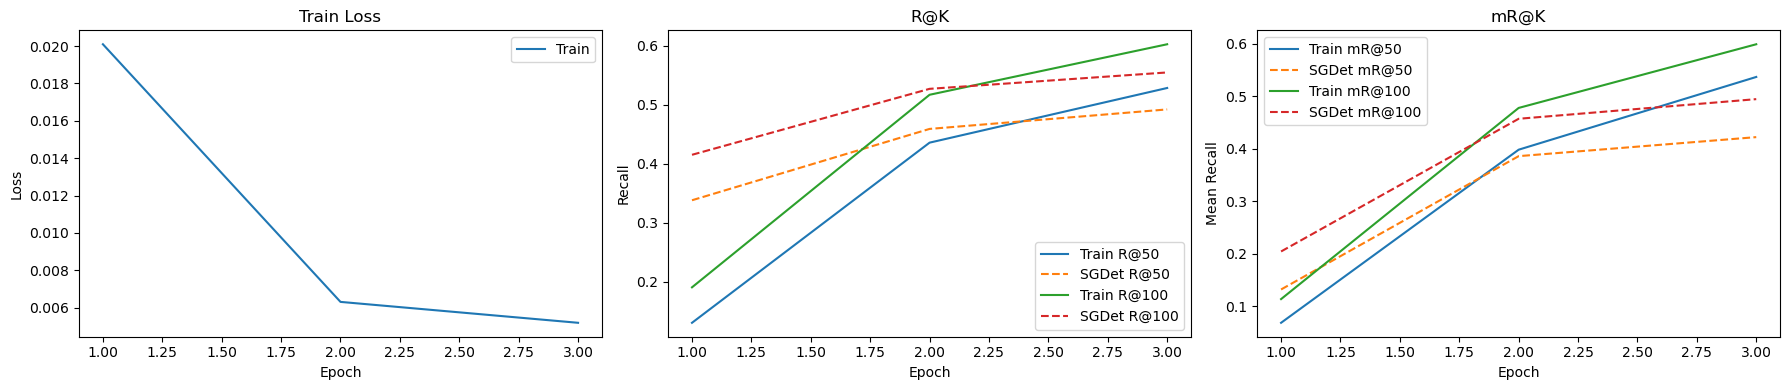

In [48]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, [h["tr_loss"] for h in history], label="Train")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].set_title("Train Loss")

for suffix, label in [("R@50", "R@50"), ("R@100", "R@100")]:
    axes[1].plot(epochs, [h[f"tr_{suffix}"] for h in history], label=f"Train {label}")
    axes[1].plot(epochs, [h[f"va_{suffix}"] for h in history], label=f"SGDet {label}", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Recall")
axes[1].legend(); axes[1].set_title("R@K")

for suffix, label in [("mR@50", "mR@50"), ("mR@100", "mR@100")]:
    axes[2].plot(epochs, [h[f"tr_{suffix}"] for h in history], label=f"Train {label}")
    axes[2].plot(epochs, [h[f"va_{suffix}"] for h in history], label=f"SGDet {label}", linestyle="--")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Mean Recall")
axes[2].legend(); axes[2].set_title("mR@K")

plt.tight_layout()
plt.show()